# Transformer Encoder Exercise (Finance)

Compare Transformer vs LSTM on financial time series.

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Load Data

In [16]:
data = yf.download("SPY", start="2018-01-01")
data["Return"] = data["Close"].pct_change()
data = data.dropna()
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2018-01-03,238.058502,238.208142,236.729443,236.729443,90070400,0.006325
2018-01-04,239.061768,239.545875,238.120011,238.700923,80636400,0.004214
2018-01-05,240.654953,240.778162,239.361108,239.853999,83524000,0.006664
2018-01-08,241.095078,241.253501,240.267719,240.558162,57319200,0.001829
2018-01-09,241.640793,242.265703,241.235897,241.517557,57254000,0.002263


## Feature Engineering

In [17]:
data["Volatility_10"] = data["Return"].rolling(10).std()
data["Momentum_5"] = data["Close"] / data["Close"].shift(5) - 1
data = data.dropna()

features = ["Return", "Volatility_10", "Momentum_5"]
values = data[features].values

## Build Sequences

In [18]:
window = 50
X, y = [], []

for i in range(len(values)-window-1):
    X.append(values[i:i+window])
    y.append(values[i+window, 0])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(2028, 50, 3) (2028,)


## Transformer Encoder Model

In [19]:
class TransformerEncoder(layers.Layer):
    def __init__(self, d_model, num_heads, dff):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads, d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, x):
        attn = self.att(x, x)
        x = self.norm1(x + attn)
        ffn = self.ffn(x)
        return self.norm2(x + ffn)

inputs = tf.keras.Input(shape=(50, len(features)))
x = TransformerEncoder(3, 4, 128)(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)

transformer_model = tf.keras.Model(inputs, outputs)
transformer_model.compile(optimizer='adam', loss='mse')
transformer_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 50, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_6           │ (None, 50, 3)          │         1,094 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 3)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,098 (4.29 KB)

 Trainable params: 1,098 (4.29 KB)

 Non-trainable params: 0 (0.00 B)

## LSTM Baseline

In [20]:
inputs = tf.keras.Input(shape=(50, len(features)))
x = layers.LSTM(64)(inputs)
outputs = layers.Dense(1)(x)

lstm_model = tf.keras.Model(inputs, outputs)
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 50, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train Models

In [21]:
print("Training Transformer...")
transformer_model.fit(X, y, epochs=3, batch_size=32)

print("Training LSTM...")
lstm_model.fit(X, y, epochs=3, batch_size=32)

Training Transformer...
Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0050 
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5083e-04
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8741e-04
Training LSTM...
Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6241e-04
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4984e-04
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5003e-04


## Compare Predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


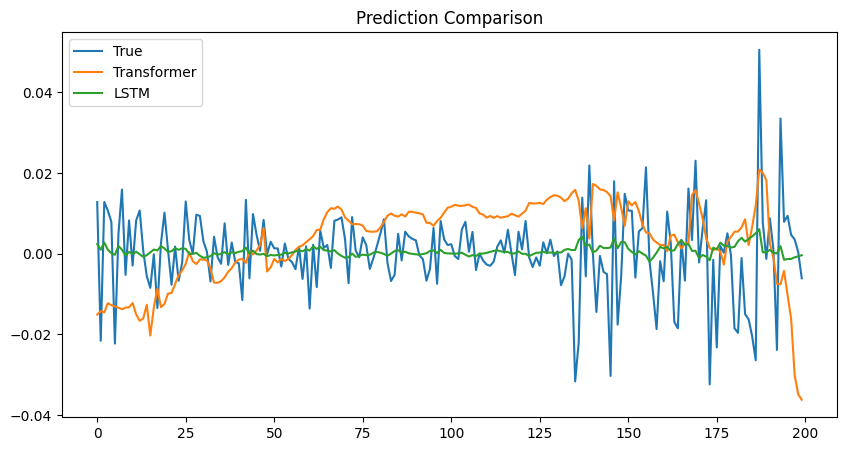

In [22]:
pred_t = transformer_model.predict(X[:200])
pred_l = lstm_model.predict(X[:200])

plt.figure(figsize=(10,5))
plt.plot(y[:200], label='True')
plt.plot(pred_t, label='Transformer')
plt.plot(pred_l, label='LSTM')
plt.legend()
plt.title("Prediction Comparison")
plt.show()

## Attention Visualization

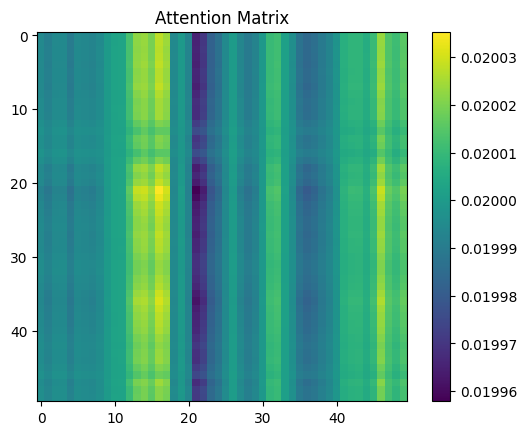

In [23]:
sample = X[0:1]
att_layer = transformer_model.layers[1].att
scores = att_layer(sample, sample, return_attention_scores=True)[1]

plt.imshow(scores[0,0])
plt.colorbar()
plt.title("Attention Matrix")
plt.show()